In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, ADASYN

In [2]:
DATA_DIR = '../data/raw/raw_data.csv'
df = pd.read_csv(DATA_DIR)

# Imbalance Analysis and Mitigation

In this section, we analyze the class imbalance present in the dataset and we provide different approaches to mitigate it. Among these different techniques, we find SMOTE, ADASYN, Oversampling and Subsampling. After handling imbalance we will save each of the resulting balanced datasets to later train and test our models.

## Visualization of the Imbalance

In the graphic bellow we observe the class imbalance previously discussed in the EDA. We clearly see that there are 2 majority classes that dominate over the other 5.

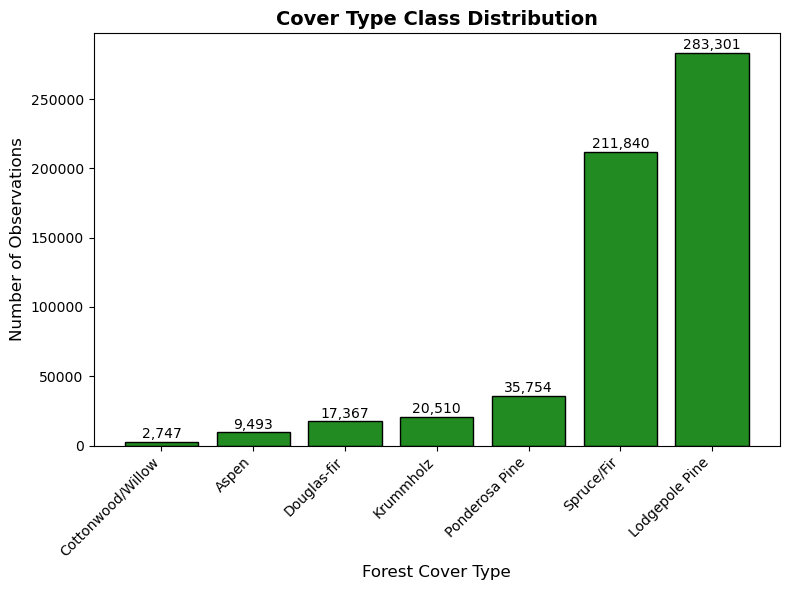

In [3]:
# Covertype Mapping
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

df['class_name'] = df['Cover_Type'].map(covertype_class)

class_counts = df['class_name'].value_counts().sort_values(ascending=True)
# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color='forestgreen', edgecolor='black')

for i, (name, count) in enumerate(zip(class_counts.index, class_counts.values)):
        plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title('Cover Type Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Mitigation Approaches
* *Oversampling*: This approach consists on generating syntehtic data from the already existing one.
    * *SMOTE*
    * *ADASYN*
* *Undersampling*: This approach consists on removing data from the majority classes. The samples removed depend on the approach followed.
    * *Random Undersampling*
    * *NearMiss*
    * *Tomek's Links*
    * *Edited Nearest Neighbors*

### OVERSAMPLING

#### SMOTE

In [4]:
from collections import Counter
X = df.drop(columns=['Cover_Type', 'class_name'], axis=1)
y = df['Cover_Type']

print(f"Shape of the dataset: {Counter(y)}")

Shape of the dataset: Counter({2: 283301, 1: 211840, 3: 35754, 7: 20510, 6: 17367, 5: 9493, 4: 2747})


In [ ]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,y)
print(f"Shape of the dataset after SMOTE: {Counter(y_resampled)}")

Shape of the dataset after SMOTE: Counter({5: 283301, 2: 283301, 1: 283301, 7: 283301, 3: 283301, 6: 283301, 4: 283301})


: 

In [ ]:
resampled_counts = pd.Series(y_resampled).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
resampled_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### ADASYN

### UNDERSAMPLING

#### RANDOM UNVERSAMPLING

#### NEARMISS

#### TOMEK'S LINKS

#### EDITED NEAREST NEIGHBORS